# Filter a noisy dataset by per-sample loss

Run a trained checkpoint over a split, compute per-image loss, keep the
bottom `KEEP_PERCENT` percentile as "good", flag the rest as "bad".

Outputs:
- `splits/{train|val}_clean.txt` — same format as the original split file,
  can be passed to training via `data.{train|val}_split=...`.
- visualization cell at the bottom to inspect bad samples one by one.

In [27]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO_ROOT = Path('/mnt/DATA2/dorin/handwriting-recognition')
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# ---- what to filter ----
CKPT_PATH     = REPO_ROOT / 'outputs' / 'dbnetpp_r18_hwr' / 'checkpoints' / 'best.pt'
CFG_PATH      = REPO_ROOT / 'config.yaml'
WHICH_SPLIT   = 'train'          # 'train' | 'val'
KEEP_PERCENT  = 95.0             # keep the bottom X% of samples by loss
USE_EMA       = True
DEVICE        = 'cuda'
OUT_SPLIT     = REPO_ROOT / 'splits' / f'{WHICH_SPLIT}_clean.txt'

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.augmentation import AugConfig
from src.dataset import PaddleOCRDetDataset, detection_collate
from src.loss import DBLoss, LossConfig
from src.model import build_model
from src.target_gen import TargetConfig

cfg = OmegaConf.load(CFG_PATH)
device = torch.device(DEVICE if torch.cuda.is_available() or DEVICE == 'cpu' else 'cpu')
print('device:', device)

device: cuda


## 1. Load model + weights

In [30]:
model = build_model(cfg)
ckpt = torch.load(CKPT_PATH, map_location='cpu')
state = ckpt['ema'] if (USE_EMA and ckpt.get('ema') is not None) else ckpt['model']
model.load_state_dict(state)
model.eval().to(device)
print('loaded:', Path(CKPT_PATH).name, '| epoch:', ckpt.get('epoch'))

loaded: best.pt | epoch: 73


## 2. Build the split dataset WITHOUT random augmentation
`tier='none'` + `train=False` → deterministic resize + pad + normalize.
This is important — we want the loss to reflect label quality, not aug randomness.

In [31]:
split_file = cfg.data.train_split if WHICH_SPLIT == 'train' else cfg.data.val_split
aug = AugConfig(tier='none', image_size=cfg.data.image_size)
tgt = TargetConfig(
    shrink_ratio=cfg.target.shrink_ratio,
    thresh_min=cfg.target.thresh_min,
    thresh_max=cfg.target.thresh_max,
)
ds = PaddleOCRDetDataset(
    dataset_root=cfg.data.dataset_root,
    labels_txt=REPO_ROOT / cfg.data.labels_txt,
    aug_cfg=aug,
    target_cfg=tgt,
    split_file=REPO_ROOT / split_file,
    min_score=cfg.data.min_score,
    train=False,
)
loader = DataLoader(ds, batch_size=1, shuffle=False,
                    num_workers=2, collate_fn=detection_collate)
print(f'{WHICH_SPLIT}: {len(ds)} samples')

train: 29744 samples


## 3. Compute per-sample loss
Same loss as training. Batch size = 1 so each `loss` value is one image.

In [32]:
loss_fn = DBLoss(LossConfig(
    alpha=cfg.loss.alpha,
    beta=cfg.loss.beta,
    ohem_ratio=cfg.loss.ohem_ratio,
    bce_weight=cfg.loss.bce_weight,
    dice_weight=cfg.loss.dice_weight,
    score_weighting=cfg.loss.score_weighting,
)).to(device)

losses, rel_paths = [], []
tensor_keys = ('prob_map', 'prob_mask', 'thresh_map', 'thresh_mask', 'score_map')

with torch.no_grad():
    for batch in tqdm(loader):
        images = batch['image'].to(device, non_blocking=True)
        for k in tensor_keys:
            batch[k] = batch[k].to(device, non_blocking=True)
        preds = model(images)
        out = loss_fn(preds, batch)
        losses.append(float(out['loss']))
        rel_paths.append(batch['rel_path'][0])

losses = np.asarray(losses, dtype=np.float32)
print(f'loss  min={losses.min():.4f}  median={np.median(losses):.4f}  max={losses.max():.4f}')

100%|██████████| 29744/29744 [16:16<00:00, 30.45it/s]

loss  min=0.2017  median=0.4380  max=11.0110


## 4. Split good / bad by percentile

threshold (p95.0): 0.7649
good: 28256   bad: 1488


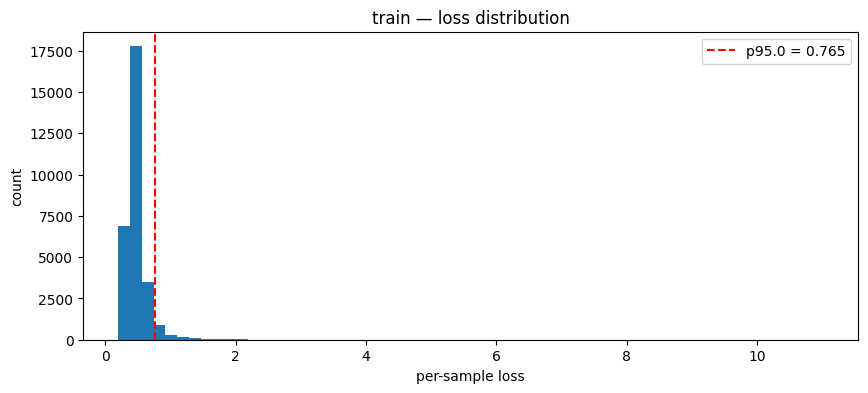

In [33]:
thresh = float(np.percentile(losses, KEEP_PERCENT))
good_mask = losses <= thresh

good = [rp for rp, m in zip(rel_paths, good_mask) if m]
bad  = sorted(
    [(rp, float(l)) for rp, l, m in zip(rel_paths, losses, good_mask) if not m],
    key=lambda x: -x[1],   # worst (highest loss) first
)
print(f'threshold (p{KEEP_PERCENT}): {thresh:.4f}')
print(f'good: {len(good)}   bad: {len(bad)}')

plt.figure(figsize=(10, 4))
plt.hist(losses, bins=60)
plt.axvline(thresh, color='r', ls='--', label=f'p{KEEP_PERCENT} = {thresh:.3f}')
plt.xlabel('per-sample loss'); plt.ylabel('count'); plt.legend()
plt.title(f'{WHICH_SPLIT} — loss distribution')
plt.savefig('../assets/train_loss.png')
plt.show()

threshold (p95.0): 0.8980
good: 3138   bad: 166


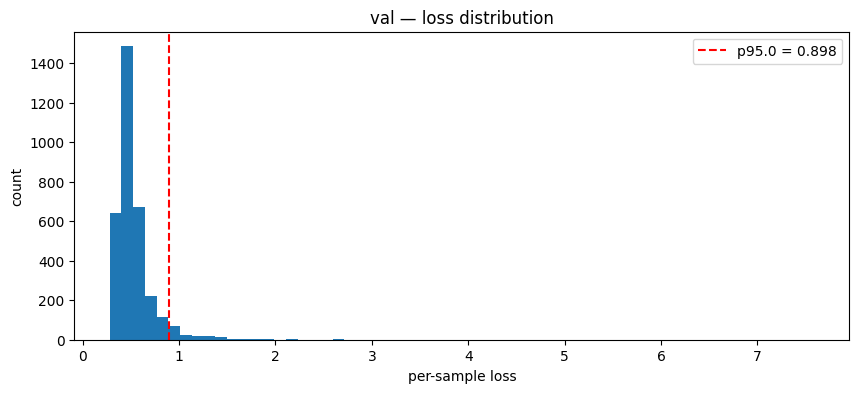

In [16]:
thresh = float(np.percentile(losses, KEEP_PERCENT))
good_mask = losses <= thresh

good = [rp for rp, m in zip(rel_paths, good_mask) if m]
bad  = sorted(
    [(rp, float(l)) for rp, l, m in zip(rel_paths, losses, good_mask) if not m],
    key=lambda x: -x[1],   # worst (highest loss) first
)
print(f'threshold (p{KEEP_PERCENT}): {thresh:.4f}')
print(f'good: {len(good)}   bad: {len(bad)}')

plt.figure(figsize=(10, 4))
plt.hist(losses, bins=60)
plt.axvline(thresh, color='r', ls='--', label=f'p{KEEP_PERCENT} = {thresh:.3f}')
plt.xlabel('per-sample loss'); plt.ylabel('count'); plt.legend()
plt.title(f'{WHICH_SPLIT} — loss distribution')
plt.savefig('../assets/val_loss.png')
plt.show()

## 5. Save the cleaned split
Same format as `splits/train.txt` / `splits/val.txt` — one rel_path per line.

In [9]:
OUT_SPLIT.parent.mkdir(parents=True, exist_ok=True)
with open(OUT_SPLIT, 'w', encoding='utf-8') as f:
    f.writelines(p + '\n' for p in good)
print('saved:', OUT_SPLIT)
print(f'\nTrain on cleaned data:')
print(f'  python train.py data.{WHICH_SPLIT}_split={OUT_SPLIT.relative_to(REPO_ROOT).as_posix()}')

saved: /mnt/DATA2/dorin/handwriting-recognition/splits/val_clean.txt

Train on cleaned data:
  python train.py data.val_split=splits/val_clean.txt


## 6. Inspect bad samples one by one
Change `BAD_IDX` (0 = worst, 1 = second worst, ...) and re-run this cell.

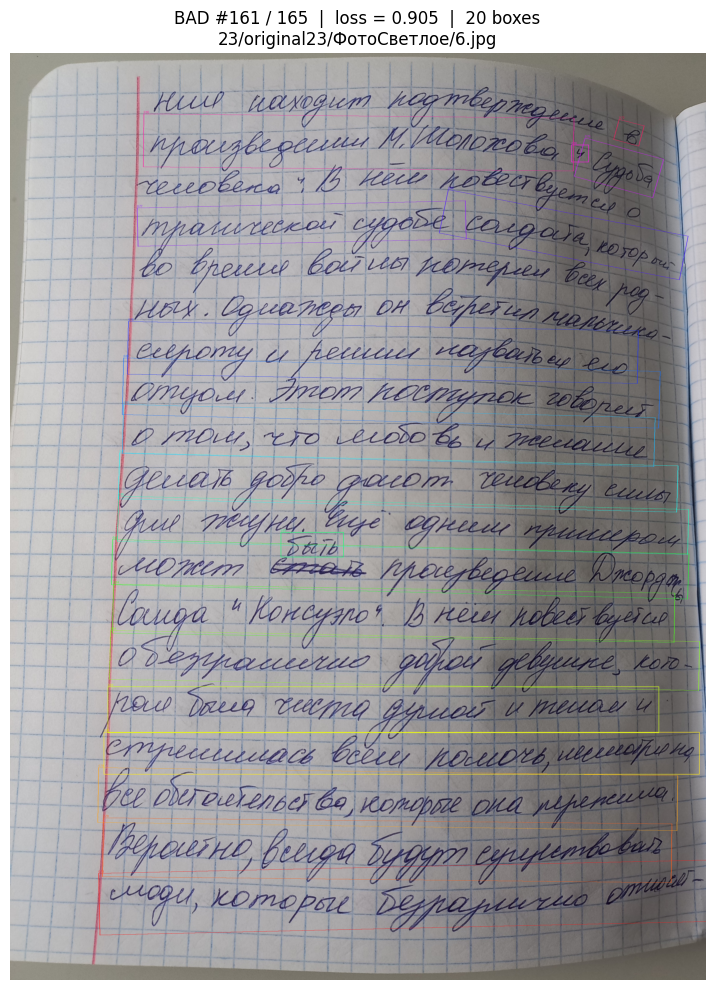

In [24]:
from PIL import Image
from src.dataset import parse_labels_txt
from src.utils import draw_polygons, preprocess_image_pil

# index -> boxes (cached once)
labels_lookup = dict(parse_labels_txt(Path(REPO_ROOT / cfg.data.labels_txt)))

BAD_IDX = 161   # (0 = worst, len(bad)-1 = mildest bad)

rel, loss_val = bad[BAD_IDX]
raw_boxes = labels_lookup[rel]
polys, scores = [], []
for b in raw_boxes:
    s = b.get('score') or 1.0
    if s < cfg.data.min_score:
        continue
    polys.append(np.asarray(b['points'], dtype=np.float32).reshape(-1, 2))
    scores.append(float(s))

img = Image.open(Path(cfg.data.dataset_root) / rel).convert('RGB')
vis = draw_polygons(img, polys, scores=scores, thickness=2)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(vis)
ax.set_title(f'BAD #{BAD_IDX} / {len(bad)-1}  |  loss = {loss_val:.3f}  |  {len(polys)} boxes\n{rel}')
ax.axis('off')
plt.tight_layout(); plt.show()

In [25]:
len(bad)

166

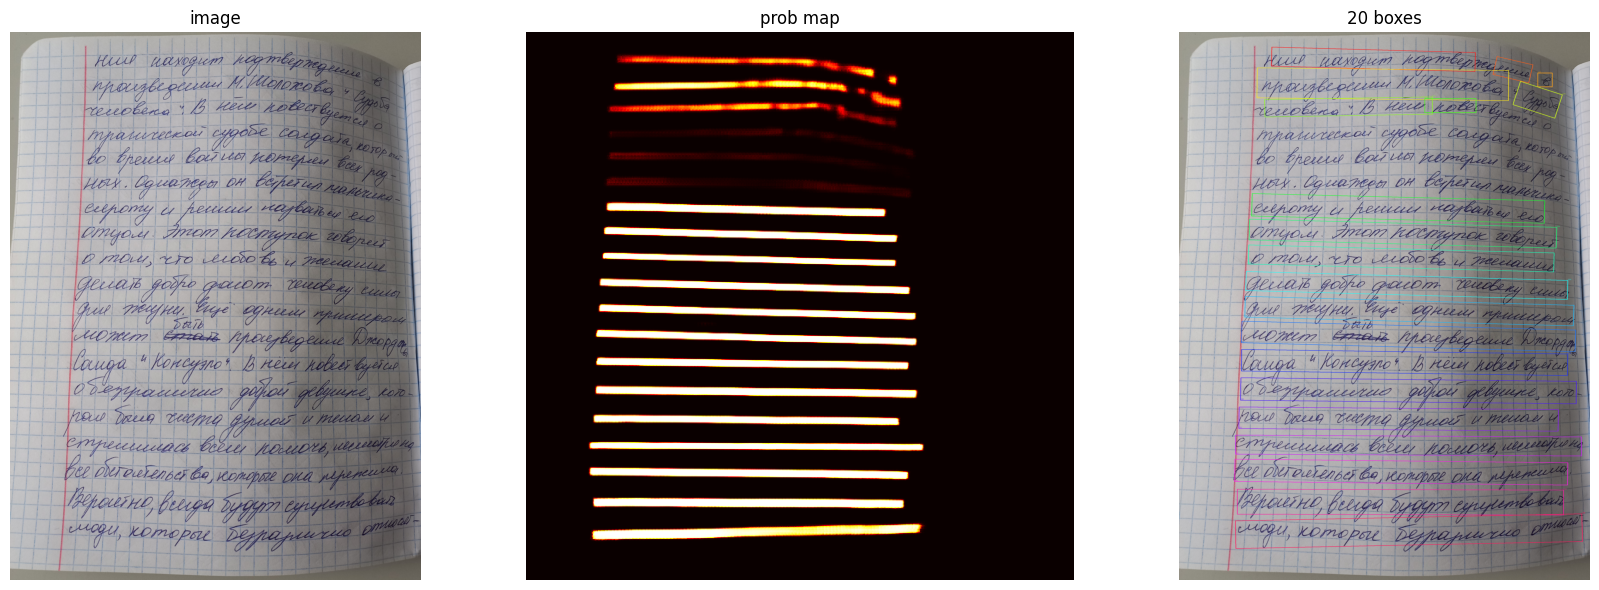

In [26]:
from src.postprocess import PostprocessConfig, decode_prob_map

tensor, meta = preprocess_image_pil(img, image_size=cfg.data.image_size)
tensor = tensor.to(device)

with torch.no_grad():
    out = model(tensor)

prob = out['prob'][0, 0].float().cpu().numpy()

post_cfg = PostprocessConfig(
    thresh         = cfg.postprocess.thresh,
    box_thresh     = cfg.postprocess.box_thresh,
    unclip_ratio   = cfg.postprocess.unclip_ratio,
    max_candidates = cfg.postprocess.max_candidates,
    min_size       = cfg.postprocess.min_size,
)

boxes, scores = decode_prob_map(
    prob,
    post_cfg,
    scale         = meta['scale'],
    pad           = (meta['pad_left'], meta['pad_top']),
    original_size = (meta['orig_w'], meta['orig_h']),
)

vis = draw_polygons(img, boxes, scores=scores, thickness=4)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img);                                   ax[0].set_title('image');    ax[0].axis('off')
ax[1].imshow(prob, cmap='hot', vmin=0, vmax=1);      ax[1].set_title('prob map'); ax[1].axis('off')
ax[2].imshow(vis);                                   ax[2].set_title(f'{len(boxes)} boxes'); ax[2].axis('off')
plt.tight_layout(); plt.show()